#### Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv('C:/Users/nimma/Downloads/IDS-PROJECT/dataset/CICIDS2017_FeatureSelected.csv')

print(df.shape)

(2520798, 40)


#### Separate Features and Target

In [4]:
X = df.drop('Label',axis=1)
y = df['Label']

#### Encode Target Label

In [5]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [6]:
label_mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

print(label_mapping)

{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}


In [7]:
import joblib as jl

jl.dump(encoder, 'C:/Users/nimma/Downloads/IDS-PROJECT/models/label_encoder.pkl')

['C:/Users/nimma/Downloads/IDS-PROJECT/models/label_encoder.pkl']

#### Check class Distribution

In [8]:
import pandas as pd

class_counts = pd.Series(y).value_counts().sort_index()

print(class_counts)

0     2095057
1        1948
2      128014
3       10286
4      172846
5        5228
6        5385
7        5931
8          11
9          36
10      90694
11       3219
12       1470
13         21
14        652
Name: count, dtype: int64


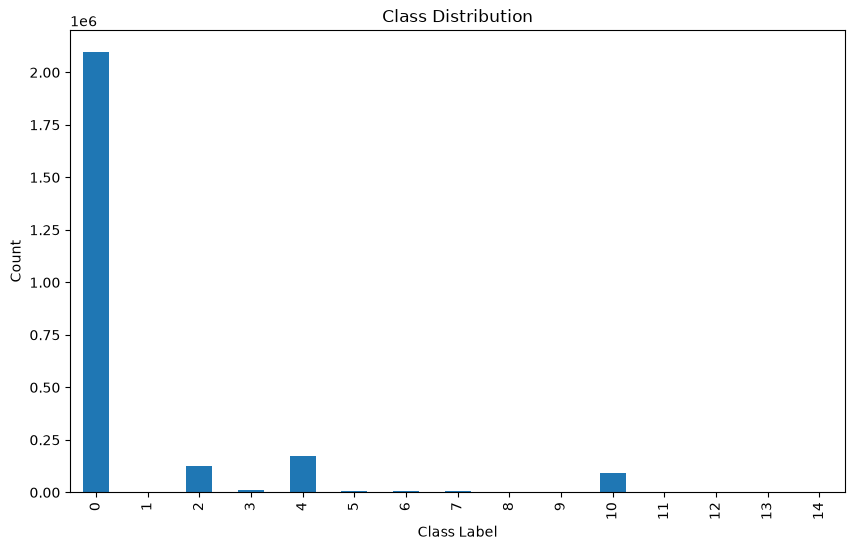

In [10]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar', figsize=(10, 6))

plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')

plt.show()

#### Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [13]:
print(f"Training set shape: {X_train.shape}, {X_test.shape}")

Training set shape: (2016638, 39), (504160, 39)


#### Validation Split

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,  # 0.25 x 0.8 = 0.2
    random_state=42,
    stratify=y_train
)

#### Feature Scaling Only for (Logistic Regression, SVM,KNN, Neural Network)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [20]:
jl.dump(scaler, 'C:/Users/nimma/Downloads/IDS-PROJECT/models/scaler.pkl')

['C:/Users/nimma/Downloads/IDS-PROJECT/models/scaler.pkl']

#### Handle Class Imbalance

In [17]:
pd.Series(y_train).value_counts()

0     1340836
4      110621
2       81929
10      58044
3        6583
7        3796
6        3446
5        3346
11       2060
1        1246
12        941
14        418
9          23
13         14
8           7
Name: count, dtype: int64

#### Save Preprocessed Data

In [18]:
jl.dump((X_train, X_val, X_test, y_train, y_val, y_test), 'C:/Users/nimma/Downloads/IDS-PROJECT/models/preprocessed_data.pkl')

['C:/Users/nimma/Downloads/IDS-PROJECT/models/preprocessed_data.pkl']